# Target : 
باشگاهی میخواهد در فصل بعدی شروع قوی داشته باشد و معتقد است اگر بر روی پوزیشنی 
سرمایهگذاری کند که معموالً هوش بسکتبالی خوبی باالیی نیاز دارد و بازیکنی توانا برای این پوزیشن
خریداری کند، میتواند شانس خود را برای موفق در فصل بعدی افزایش دهد. به همین دلیل میخواهد
بازیکنی در پوزیشن Guard Point خریداری کند که توانایی باالیی داشته باشد. معیار توانایی برای این
باشگاه، وجود بازیکن در لیست Trophy Jordan Michael میباشد و بازیکنی که حضور بیشتری داشته،
اولویت باالتری دارد. لیستی از بازیکنان مناسب برای خرید با توجه به آمار فصلها از فصل ۲۰۲۰-۲۰۱۹ تا
پایان ۲۰۲۴-۲۰۲۳ تهیه کنید و ۳ پیشنهاد به این باشگاه ارائه دهید.

# Adding Libraries and connecting to database

In [28]:
import mysql.connector
from mysql.connector import errorcode
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
config = {    
  'user': 'root',
  'password': '*',  
  'host': 'localhost',
  'database': 'project3'
}

DB_NAME = 'project3' 

In [30]:
try:
    
    cnxn = mysql.connector.connect(**config)
    cursor = cnxn.cursor()
    print("✅ Connected to project3 database.")


except mysql.connector.Error as err:
    print(f"❌ Connection or execution error: {err}")

finally:
    if 'cnxn' in locals() and cnxn.is_connected():
        cursor.close()
        cnxn.close()
        print("✅ Connection closed.")

✅ Connected to project3 database.
✅ Connection closed.


# Executing the query and making the output dataframe

In [31]:
try:    
    with mysql.connector.connect(**config) as cnxn:
        query = """

        select players.player_name as 'player name', count(players.player_id) as mvp_nomination_count
        from players
         join mvp_candidates
              on players.player_id = mvp_candidates.player_id
         join player_stats
              on mvp_candidates.player_id = player_stats.player_id and player_stats.season = mvp_candidates.year
        where player_stats.position = 'PG'
        and player_stats.season between 2020 and 2024
        group by players.player_id
        order by mvp_nomination_count desc;

        """
        
        df_Q3 = pd.read_sql(query, cnxn)
        display(df_Q3)
        

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")
print(df_Q3.iloc[0, 0])
df_Q3.iloc[0, 0] = 'Luka Dončić'



C:\Users\Asus\AppData\Local\Temp\ipykernel_26116\3539238502.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_Q3 = pd.read_sql(query, cnxn)


,player name,mvp_nomination_count
0,luka donäiä,5
1,chris paul,3
2,stephen curry,3
3,lebron james,2
4,damian lillard,2
5,ja morant,2
6,jalen brunson,2
7,shai gilgeous-alexander,2
8,james harden,1
9,derrick rose,1


luka donäiä


# Showing the dataframe on barplot

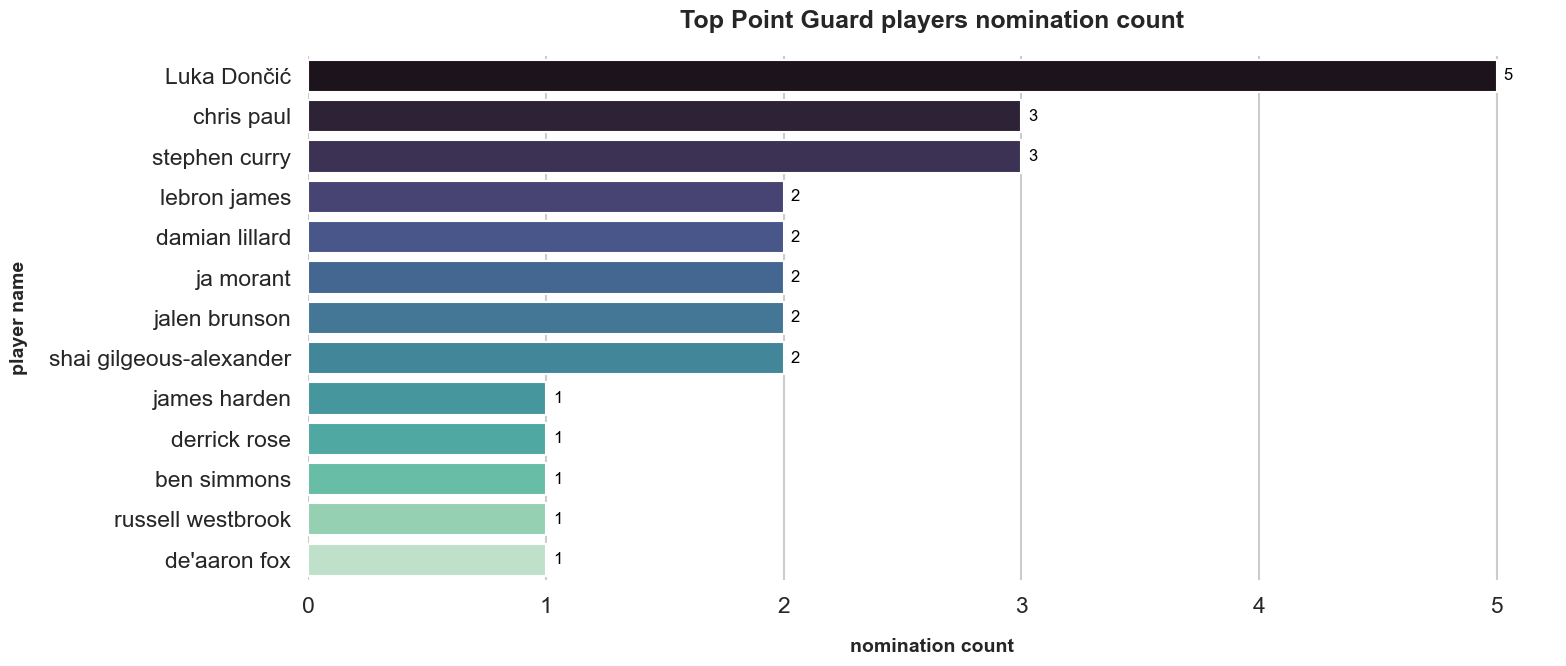

In [32]:
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(16, 7))

ax = sns.barplot(
    x='mvp_nomination_count', 
    y='player name', 
    data=df_Q3,
    palette="mako" 
)

ax.bar_label(
    ax.containers[0], 
    label_type='edge',
    padding=5,
    color='black',
    fontsize=12
)


plt.title('Top Point Guard players nomination count', fontsize=18, weight='bold', pad=20)
plt.xlabel('nomination count', fontsize=14, weight = 'bold', labelpad=15)
plt.ylabel('player name', fontsize=14, weight = 'bold', labelpad=15)


sns.despine(left=True, bottom=True) 
plt.tight_layout()
plt.show()

# Now which player to pick with 2 nominations?

In [33]:
# looking for the best player with 2 nominations based on their average rank in their mvp nominations

try:    
    with mysql.connector.connect(**config) as cnxn:
        query = """

       select players.player_name as 'player name',count(players.player_id) as mvp_nomination_count, avg(mvp_candidates.rank) as 'average rank'
       from players
         join mvp_candidates
              on players.player_id = mvp_candidates.player_id
         join player_stats
              on mvp_candidates.player_id = player_stats.player_id and player_stats.season = mvp_candidates.year
       where player_stats.position = 'PG'
       and player_stats.season between 2020 and 2024
       and players.player_name in (
            'LeBron James', 'Damian Lillard', 'Ja Morant',
              'Jalen Brunson', 'Shai Gilgeous-Alexander'
            )
       group by players.player_id
       order by `average rank` asc ;

        """
        
        df_Q3_extra = pd.read_sql(query, cnxn)
        display(df_Q3_extra)
        

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")

C:\Users\Asus\AppData\Local\Temp\ipykernel_26116\2454254131.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_Q3_extra = pd.read_sql(query, cnxn)


,player name,mvp_nomination_count,average rank
0,shai gilgeous-alexander,2,3.5
1,lebron james,2,7.5
2,damian lillard,2,7.5
3,jalen brunson,2,8.5
4,ja morant,2,9.5


# Showing their average rank on their previous nominations

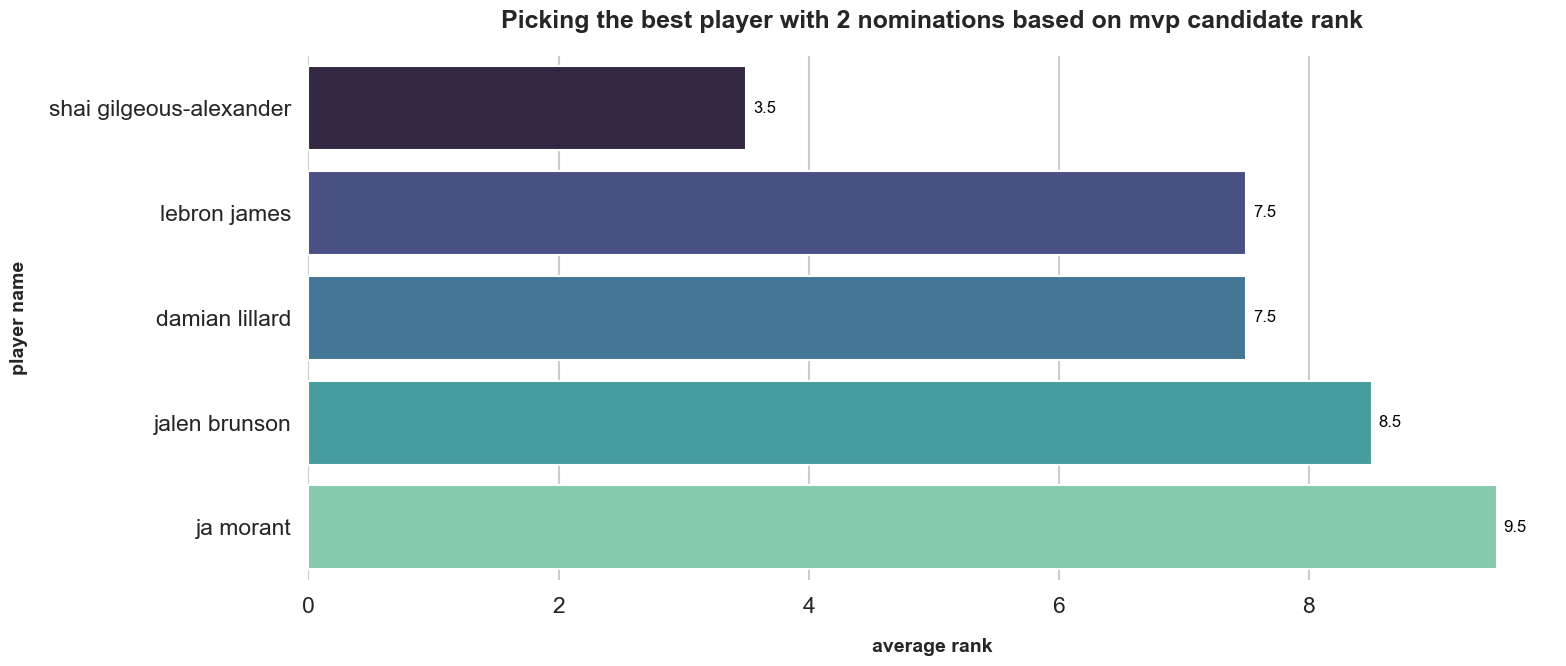

In [34]:
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(16, 7))

ax = sns.barplot(
    x='average rank', 
    y='player name', 
    data=df_Q3_extra,
    palette="mako" 
)

ax.bar_label(
    ax.containers[0], 
    label_type='edge',
    padding=5,
    color='black',
    fontsize=12
)


plt.title('Picking the best player with 2 nominations based on mvp candidate rank', fontsize=18, weight='bold', pad=20)
plt.xlabel('average rank', fontsize=14, weight = 'bold', labelpad=15)
plt.ylabel('player name', fontsize=14, weight = 'bold', labelpad=15)


sns.despine(left=True, bottom=True) 
plt.tight_layout()
plt.show()

# Based on what we saw :
* **1st_pick : Luka Dončić**
* **2nd_pick : chris paul**
* **3rd_pick : stephen curry**

# Top5 picks
* **1st_pick : Luka Dončić**
* **2nd_pick : chris paul**
* **3rd_pick : stephen curry**
* **4th_pick : shai gilgeous-alexander**
* **5th_pick : lebron james or Damian Lillard**